# RHCR Learned Results (Multiple Configs)

读取 `RHCR/exp` 下多个 learned 配置目录，画 `throughput` 和 `time`（由 `run.log` 解析）。

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 60)


In [2]:
# ===== 配置 =====
exp_root = Path('/home/shiqi/masterarbeit/RHCR/exp')

# 方式1：自动扫描 exp 下含 summary.csv 的目录
run_dirs = sorted([d for d in exp_root.rglob('*') if d.is_dir() and (d / 'summary.csv').exists()])

# 方式2：手动指定（取消注释）
# run_dirs = [
#     Path('/home/shiqi/masterarbeit/RHCR/exp/rhcr_eval_runs/rhcr_compare_20260510_072748'),
# ]

assert run_dirs, f'No result dirs with summary.csv found under {exp_root}'
print('found runs:', len(run_dirs))
for d in run_dirs[:10]:
    print('-', d)
if len(run_dirs) > 10:
    print('...')

x_key = 'num_agents'
x_label = 'agent_num'
fig_w, fig_h, line_w = 5.5, 5.0, 2.0


found runs: 2
- /home/shiqi/masterarbeit/RHCR/exp/rhcr_eval_runs/rhcr_compare_20260510_072748
- /home/shiqi/masterarbeit/RHCR/exp/rhcr_eval_runs/rhcr_compare_20260510_163006


In [3]:
def parse_solver_times(run_log: Path):
    if not run_log.exists():
        return []
    out = []
    for ln in run_log.read_text(encoding='utf-8', errors='ignore').splitlines():
        if ':Succeed,' not in ln:
            continue
        try:
            payload = ln.split(':Succeed,', 1)[1]
            t = float(payload.split(',', 1)[0])
            out.append(t)
        except Exception:
            pass
    return out

records = []
for rd in run_dirs:
    df = pd.read_csv(rd / 'summary.csv')
    # 仅 learned
    if 'mode' in df.columns:
        df = df[df['mode'] == 'learned'].copy()
    if df.empty:
        continue

    label = rd.name
    for _, r in df.iterrows():
        if str(r.get('status', '')) != 'ok':
            continue
        run_dir = Path(str(r['run_dir']))
        times = parse_solver_times(run_dir / 'run.log')
        mean_t = float(np.mean(times)) if len(times) else np.nan
        sum_t = float(np.sum(times)) if len(times) else np.nan

        records.append({
            'config': label,
            'num_agents': int(r['num_agents']),
            'seed': int(r['seed']),
            'throughput_per_step': float(r['throughput_per_step']),
            'mean_solver_time': mean_t,
            'sum_solver_time': sum_t,
        })

all_df = pd.DataFrame(records)
assert not all_df.empty, 'No learned rows found.'
display(all_df.head(20))
print('configs:', sorted(all_df['config'].unique()))


,config,num_agents,seed,throughput_per_step,mean_solver_time,sum_solver_time
0,rhcr_compare_20260510_072748,32,10,1.218750,0.005420,1.387544
1,rhcr_compare_20260510_072748,32,11,1.179688,0.006443,1.649340
2,rhcr_compare_20260510_072748,32,12,1.195312,0.006398,1.637882
3,rhcr_compare_20260510_072748,32,13,1.230469,0.004641,1.188122
4,rhcr_compare_20260510_072748,32,14,1.203125,0.005077,1.299731
5,rhcr_compare_20260510_072748,32,15,1.222656,0.004944,1.265588
6,rhcr_compare_20260510_072748,32,16,1.210938,0.005145,1.317049
7,rhcr_compare_20260510_072748,32,17,1.179688,0.005531,1.415837
8,rhcr_compare_20260510_072748,32,18,1.187500,0.004741,1.213700
9,rhcr_compare_20260510_072748,32,19,1.156250,0.006167,1.578776


configs: ['rhcr_compare_20260510_072748', 'rhcr_compare_20260510_163006']


In [4]:
# 聚合 throughput
agg_thr = (all_df.groupby(['config', 'num_agents'])['throughput_per_step']
           .agg(['mean','std','count'])
           .reset_index())
agg_thr['sem'] = agg_thr['std'] / np.sqrt(agg_thr['count'].clip(lower=1))
agg_thr['ci95'] = 1.96 * agg_thr['sem']
display(agg_thr.sort_values(['num_agents','config']))

# 聚合 time（每次规划调用平均时间）
agg_time = (all_df.dropna(subset=['mean_solver_time'])
            .groupby(['config', 'num_agents'])['mean_solver_time']
            .agg(['mean','std','count'])
            .reset_index())
agg_time['sem'] = agg_time['std'] / np.sqrt(agg_time['count'].clip(lower=1))
agg_time['ci95'] = 1.96 * agg_time['sem']
display(agg_time.sort_values(['num_agents','config']))


,config,num_agents,mean,std,count,sem,ci95
0,rhcr_compare_20260510_072748,32,1.198438,0.023132,10,0.007315,0.014337
6,rhcr_compare_20260510_163006,32,1.202344,0.043373,10,0.013716,0.026883
1,rhcr_compare_20260510_072748,64,2.250391,0.046419,10,0.014679,0.028771
7,rhcr_compare_20260510_163006,64,2.210547,0.044669,10,0.014126,0.027686
2,rhcr_compare_20260510_072748,96,3.147656,0.041740,10,0.013199,0.025871
8,rhcr_compare_20260510_163006,96,3.112109,0.050933,10,0.016106,0.031569
3,rhcr_compare_20260510_072748,128,4.029297,0.077345,10,0.024459,0.047939
9,rhcr_compare_20260510_163006,128,3.916406,0.074486,10,0.023554,0.046167
4,rhcr_compare_20260510_072748,160,4.853125,0.075548,10,0.023890,0.046825
10,rhcr_compare_20260510_163006,160,4.727734,0.064188,10,0.020298,0.039784


,config,num_agents,mean,std,count,sem,ci95
0,rhcr_compare_20260510_072748,32,0.005451,0.000671,10,0.000212,0.000416
6,rhcr_compare_20260510_163006,32,0.031003,0.004479,10,0.001416,0.002776
1,rhcr_compare_20260510_072748,64,0.028072,0.002432,10,0.000769,0.001507
7,rhcr_compare_20260510_163006,64,0.145321,0.011298,10,0.003573,0.007003
2,rhcr_compare_20260510_072748,96,0.083842,0.007741,10,0.002448,0.004798
8,rhcr_compare_20260510_163006,96,0.388912,0.029349,10,0.009281,0.018191
3,rhcr_compare_20260510_072748,128,0.195256,0.010610,10,0.003355,0.006576
9,rhcr_compare_20260510_163006,128,0.803109,0.045695,10,0.014450,0.028322
4,rhcr_compare_20260510_072748,160,0.388766,0.024322,10,0.007691,0.015075
10,rhcr_compare_20260510_163006,160,1.528835,0.070125,10,0.022175,0.043464


Saved: /home/shiqi/masterarbeit/RHCR/exp/learned_throughput_compare.pdf


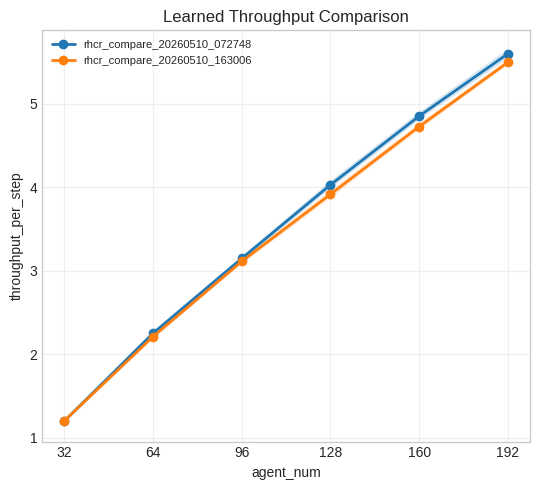

In [5]:
# 图1: throughput
plt.figure(figsize=(fig_w, fig_h))
for cfg in sorted(agg_thr['config'].unique()):
    sub = agg_thr[agg_thr['config'] == cfg].sort_values('num_agents')
    x = sub['num_agents'].tolist()
    y = sub['mean'].tolist()
    c = sub['ci95'].fillna(0).tolist()
    plt.plot(x, y, marker='o', linewidth=line_w, label=cfg)
    plt.fill_between(x, [yy-cc for yy,cc in zip(y,c)], [yy+cc for yy,cc in zip(y,c)], alpha=0.18)

plt.title('Learned Throughput Comparison')
plt.xlabel(x_label)
plt.ylabel('throughput_per_step')
xt = sorted([int(v) for v in agg_thr['num_agents'].dropna().unique().tolist()])
if xt:
    plt.xticks(xt)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
out1 = exp_root / 'learned_throughput_compare.pdf'
plt.savefig(out1)
print('Saved:', out1)
plt.show()


Saved: /home/shiqi/masterarbeit/RHCR/exp/learned_time_compare.pdf


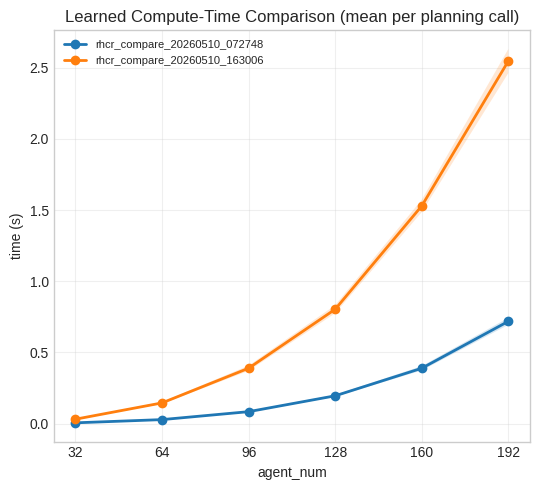

In [6]:
# 图2: time（每次规划调用平均时间）
plt.figure(figsize=(fig_w, fig_h))
for cfg in sorted(agg_time['config'].unique()):
    sub = agg_time[agg_time['config'] == cfg].sort_values('num_agents')
    x = sub['num_agents'].tolist()
    y = sub['mean'].tolist()
    c = sub['ci95'].fillna(0).tolist()
    plt.plot(x, y, marker='o', linewidth=line_w, label=cfg)
    plt.fill_between(x, [yy-cc for yy,cc in zip(y,c)], [yy+cc for yy,cc in zip(y,c)], alpha=0.18)

plt.title('Learned Compute-Time Comparison (mean per planning call)')
plt.xlabel(x_label)
plt.ylabel('time (s)')
xt = sorted([int(v) for v in agg_time['num_agents'].dropna().unique().tolist()])
if xt:
    plt.xticks(xt)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
out2 = exp_root / 'learned_time_compare.pdf'
plt.savefig(out2)
print('Saved:', out2)
plt.show()
